In [46]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
from functions.processing import create_dataframe
DATA_PATH = "Data/"

# 🏥 **Identification of Invasive Ductal Carcinoma (IDC) in Biopsy Slides**  

## 📌 **Repository Objective**  
This repository aims to develop an approach to **identify invasive ductal carcinoma (IDC)** in breast cancer biopsy slide images using image processing techniques and machine learning.  

## 🩺 **What is IDC?**  
**Invasive Ductal Carcinoma (IDC)** is the most common type of breast cancer, accounting for **about 80% of invasive cases**. It originates in the **milk ducts**, the channels that transport milk from the mammary glands to the nipple.  

The term **"invasive"** means that the cancer has broken through the duct walls and spread to the **surrounding breast tissue**, potentially reaching the **lymph nodes** and even distant organs (**metastasis**).  

## 📊 **Dataset Structure and Distribution**  
The dataset used is available on Kaggle:  
🔗 [Breast Histopathology Images](https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images/data)  

### 🔹 **Organization**  
- The dataset is divided into **folders**, each corresponding to a **patient**.  
- Inside each folder, there are **cropped images** (_patches_) extracted from biopsy slides.  
- Each image is **50x50 pixels** and is **classified** as **IDC positive (1)** or **IDC negative (0)**.  

## 🖼️ **Image Format**  
Each image follows a standardized naming format:  

`u_xX_yY_classC.png`  

### 🔍 **Example Filename:**  

`10253_idx5_x1351_y1101_class0.png`  

### 📖 **Explanation:**  

| Element   | Meaning |
|-----------|---------|
| `10253_idx5` | **Patient ID** and scanned slide number |
| `x1351` | **X coordinate** of the cropped patch |
| `y1101` | **Y coordinate** of the cropped patch |
| `class0` | **Image class** (0 = IDC negative, 1 = IDC positive) |

This naming convention allows tracking the patch's origin within the original slide, facilitating the spatial analysis of cancerous cells.  

---  
✨ **With this repository, we aim to assist in breast cancer diagnosis, contributing to research and innovation in healthcare.**  


In [47]:
'''
!mkdir Data
!cd Data
!curl -L -o Data/breast-histopathology-images.zip\
!https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/breast-histopathology-images
!unzip breast-histopathology-images.zip
!rm breast-histopathology-images.zip
'''

'\n!mkdir Data\n!cd Data\n!curl -L -o Data/breast-histopathology-images.zip!https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/breast-histopathology-images\n!unzip breast-histopathology-images.zip\n!rm breast-histopathology-images.zip\n'

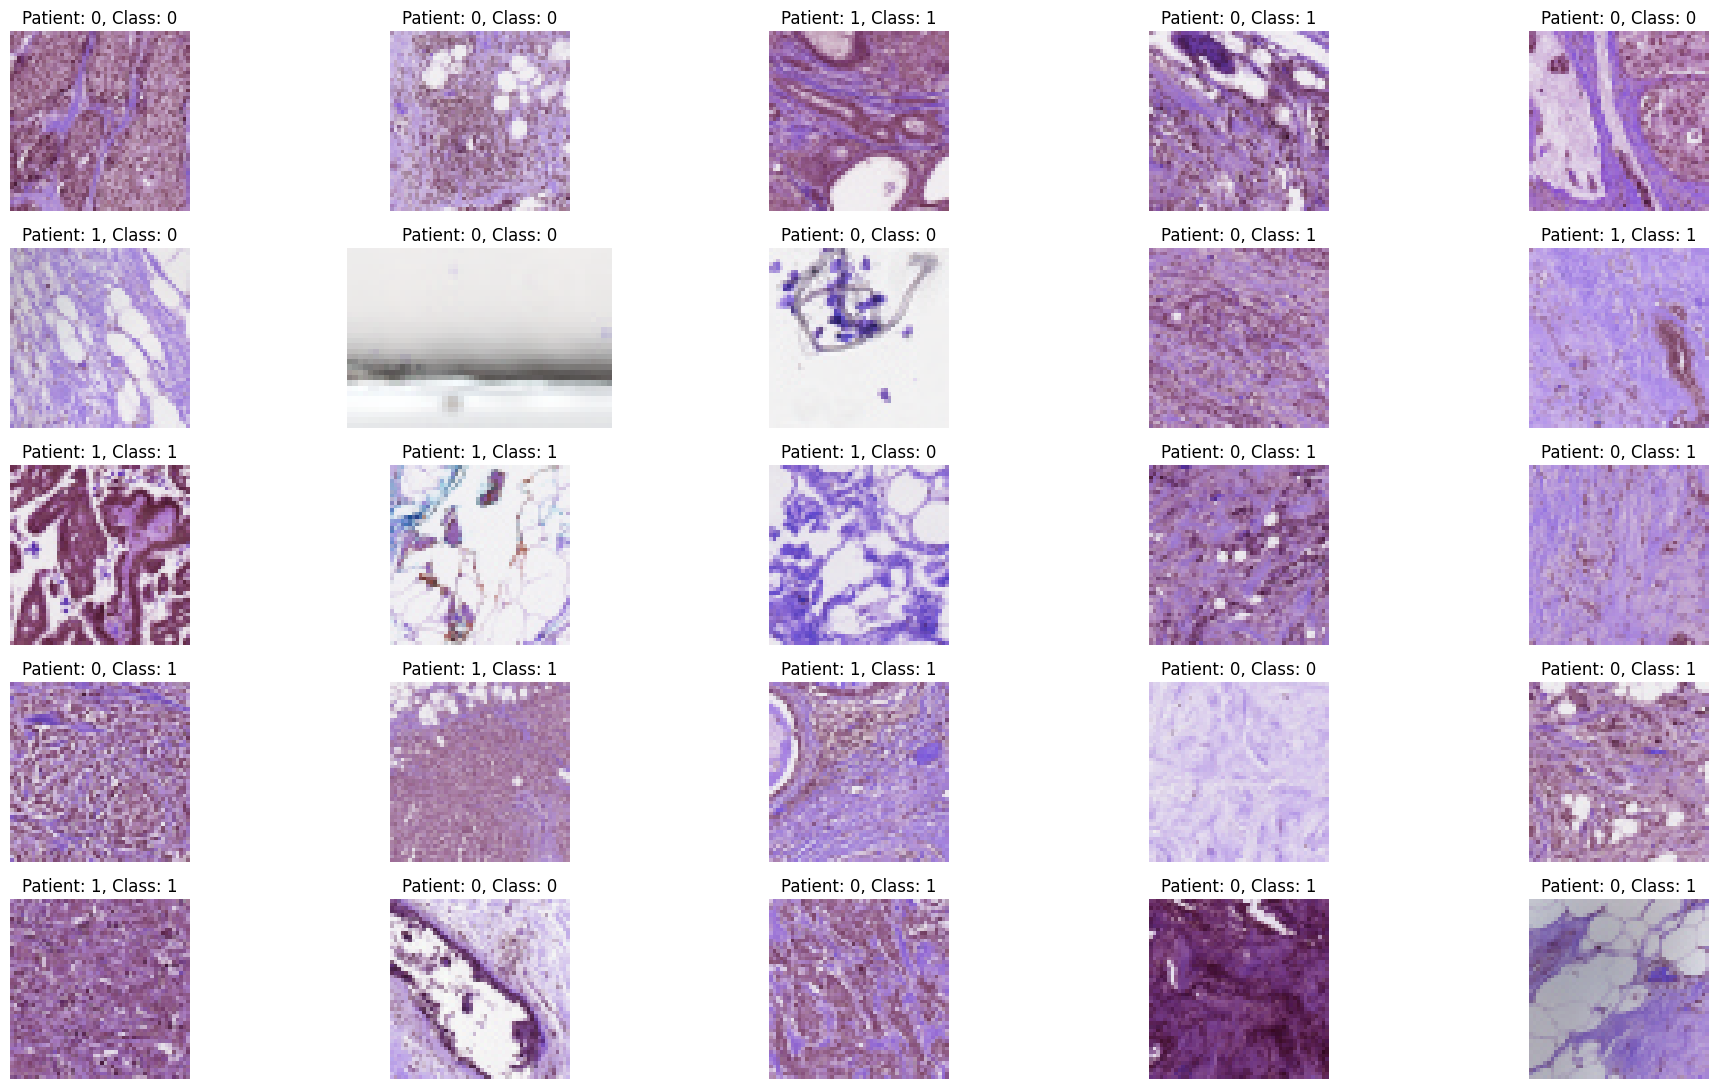

In [48]:
import random

PATIENT_ID = os.listdir(DATA_PATH)
num_images = 25  
fig, axes = plt.subplots(5, 5, figsize=(20, 11))  
axes = axes.flatten()  

for ax in axes:
    patient_id = random.choice(PATIENT_ID)
    class_label = random.choice(["0", "1"])
    image_file = random.choice(os.listdir(DATA_PATH + "/" + class_label))
    image_path = os.path.join(DATA_PATH, class_label, image_file)
    image = cv2.imread(image_path)
    ax.imshow(image, cmap="BrBG")
    ax.set_title(f"Patient: {patient_id}, Class: {class_label}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [49]:
df = create_dataframe("Data")
df

,image_path,label
0,Data/0/9320_idx5_x601_y301_class0.png,0
1,Data/0/10282_idx5_x1701_y901_class0.png,0
2,Data/0/9073_idx5_x2301_y751_class0.png,0
3,Data/0/12910_idx5_x1801_y551_class0.png,0
4,Data/0/10253_idx5_x1201_y801_class0.png,0
...,...,...
555043,Data/1/12907_idx5_x2251_y2251_class1.png,1
555044,Data/1/14211_idx5_x1901_y1351_class1.png,1
555045,Data/1/9176_idx5_x1401_y1451_class1.png,1
555046,Data/1/13404_idx5_x1901_y1801_class1.png,1


In [50]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

In [51]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
import torch

class ImagePathDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)


        
    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, 'image_path']
        label = self.dataframe.loc[idx, 'label']

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # 🔄 Converte label para float antes de tensor
        label = float(label)  # <- converte string para float
        label = torch.tensor(label, dtype=torch.float32)

        return image, label



In [52]:
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_dataset = ImagePathDataset(train_df, transform=transform)
test_dataset = ImagePathDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # entrada RGB
        self.pool = nn.MaxPool2d(2, 2)  # reduz dimensão pela metade
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 32 * 32, 64)  # Flatten + FC
        self.fc2 = nn.Linear(64, 1)  # Saída binária

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # [B, 16, 64, 64]
        x = self.pool(F.relu(self.conv2(x)))   # [B, 32, 32, 32]
        x = x.view(-1, 32 * 32 * 32)            # Flatten
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))          # saída entre 0 e 1
        return x


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)  # agora sim: [B, 1]


        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
